# Домашнее задание 1. Знакомство с API
Студент: *ФИО*, группа, дата

Задание выполняется в рамках модуля 1 «Проектирование API». Вы закрепите навыки разработки API, используя подход API-first.

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

## Подготовка окружения

In [1]:
!pip install requests -qqq

### Задание 1. Создать CRUD на основе встроенного HTTP сервера Python

Задача: создать сервер, который будет содержать код API с двумя методами HTTP.

*Здесь мы **специально** берем сильно устаревшую версию веб-сервера, написанную во времена Python 2.0 в 2000 году. Обратите внимание на многословность кода веб-сервера.*


In [2]:
import http.server
import socketserver
import json
import re
import threading
import subprocess
import pandas as pd
import datetime

In [3]:
import pandas as pd
import datetime
df = pd.DataFrame([['Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг',
  1025,
  329,
  11,
  'c',
  'антифриз',
  datetime.datetime(2026, 10, 16, 12, 36, 22)],
 ['Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг',
  250,
  315,
  38,
  'b',
  'антифриз',
  datetime.datetime(2025, 12, 11, 8, 25, 31)],
 ['Антифриз G11 зеленый',
  120,
  329,
  61,
  'b',
  'антифриз',
  datetime.datetime(2025, 6, 15, 15, 36, 30)],
 ['Антифриз Antifreeze OEM China OAT red -40 5кг',
  390,
  504,
  65,
  'c',
  'антифриз',
  datetime.datetime(2025, 11, 30, 4, 12, 39)],
 ['Антифриз G11 зеленый',
  135,
  407,
  93,
  'b',
  'антифриз',
  datetime.datetime(2026, 8, 25, 3, 24, 1)],
])

df.columns = ['Наименование товара', 'Цена, руб.', 'cpm', 'Скидка', 'tp', 'Категория', 'dt']
df['Год'] = df['dt'].dt.year
df=df.drop(['cpm',  'tp', 'dt'],axis=1)
display(df)


,Наименование товара,"Цена, руб.",Скидка,Категория,Год
0,"Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг",1025,11,антифриз,2026
1,Антифриз готовый фиолетовый Синтек MULTIFREEZE...,250,38,антифриз,2025
2,Антифриз G11 зеленый,120,61,антифриз,2025
3,Антифриз Antifreeze OEM China OAT red -40 5кг,390,65,антифриз,2025
4,Антифриз G11 зеленый,135,93,антифриз,2026


In [4]:
items_db = []
next_id = 1
for idx, row in df.iterrows():
    items_db.append({
        "id": next_id,
        "name": row["Наименование товара"],
        "price": row["Цена, руб."],
        "discount": row["Скидка"],
        "category": row["Категория"],
        "year": int(row["Год"])
    })
    next_id += 1

In [5]:
class SimpleCRUDHandler(http.server.BaseHTTPRequestHandler):

    def _send_json_response(self, status_code, data=None):
        self.send_response(status_code)
        self.send_header('Content-type', 'application/json')
        self.end_headers()
        if data is not None:
            self.wfile.write(json.dumps(data, ensure_ascii=False).encode('utf-8'))

    def _parse_json_body(self):
        content_length = int(self.headers.get('Content-Length', 0))
        if content_length == 0:
            return None
        body = self.rfile.read(content_length)
        try:
            return json.loads(body.decode('utf-8'))
        except json.JSONDecodeError:
            return None

    def do_GET(self):
        # GET /items - список всех товаров
        if re.match(r'^/items/?$', self.path):
            self._send_json_response(200, items_db)
            return

        # GET /items/{id} - один товар
        match = re.match(r'^/items/([0-9]+)/?$', self.path)
        if match:
            item_id = int(match.group(1))
            item = next((i for i in items_db if i["id"] == item_id), None)
            if item:
                self._send_json_response(200, item)
            else:
                self._send_json_response(404, {"detail": "Item not found"})
            return

        self._send_json_response(404, {"detail": "Not Found"})

    def do_POST(self):
        # POST /items - создание нового товара
        if not re.match(r'^/items/?$', self.path):
            self._send_json_response(404, {"detail": "Not Found"})
            return

        body = self._parse_json_body()
        if body is None:
            self._send_json_response(400, {"detail": "Invalid JSON"})
            return

        # Проверяем обязательные поля
        required_fields = ["name", "price", "discount", "category", "year"]
        for field in required_fields:
            if field not in body:
                self._send_json_response(400, {"detail": f"Missing field: {field}"})
                return

        global next_id
        new_item = {
            "id": next_id,
            "name": body["name"],
            "price": body["price"],
            "discount": body["discount"],
            "category": body["category"],
            "year": body["year"]
        }
        items_db.append(new_item)
        next_id += 1
        self._send_json_response(201, new_item)

    def do_PUT(self):
        # PUT /items/{id} - полное обновление товара
        match = re.match(r'^/items/([0-9]+)/?$', self.path)
        if not match:
            self._send_json_response(404, {"detail": "Not Found"})
            return

        item_id = int(match.group(1))
        body = self._parse_json_body()
        if body is None:
            self._send_json_response(400, {"detail": "Invalid JSON"})
            return

        # Ищем товар
        for i, item in enumerate(items_db):
            if item["id"] == item_id:
                # Обновляем все поля
                updated_item = {
                    "id": item_id,
                    "name": body.get("name", item["name"]),
                    "price": body.get("price", item["price"]),
                    "discount": body.get("discount", item["discount"]),
                    "category": body.get("category", item["category"]),
                    "year": body.get("year", item["year"])
                }
                items_db[i] = updated_item
                self._send_json_response(200, updated_item)
                return
        self._send_json_response(404, {"detail": "Item not found"})

    def do_DELETE(self):
        # DELETE /items/{id} - удаление товара
        match = re.match(r'^/items/([0-9]+)/?$', self.path)
        if not match:
            self._send_json_response(404, {"detail": "Not Found"})
            return

        item_id = int(match.group(1))
        for i, item in enumerate(items_db):
            if item["id"] == item_id:
                deleted = items_db.pop(i)
                self._send_json_response(200, {"detail": "Deleted", "item": deleted})
                return
        self._send_json_response(404, {"detail": "Item not found"})

In [6]:
items_db

[{'id': 1,
  'name': 'Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг',
  'price': 1025,
  'discount': 11,
  'category': 'антифриз',
  'year': 2026},
 {'id': 2,
  'name': 'Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг',
  'price': 250,
  'discount': 38,
  'category': 'антифриз',
  'year': 2025},
 {'id': 3,
  'name': 'Антифриз G11 зеленый',
  'price': 120,
  'discount': 61,
  'category': 'антифриз',
  'year': 2025},
 {'id': 4,
  'name': 'Антифриз Antifreeze OEM China OAT red -40 5кг',
  'price': 390,
  'discount': 65,
  'category': 'антифриз',
  'year': 2025},
 {'id': 5,
  'name': 'Антифриз G11 зеленый',
  'price': 135,
  'discount': 93,
  'category': 'антифриз',
  'year': 2026}]

In [7]:
PORT = 8000
httpd = None

In [8]:
def free_port(port):
    global httpd
    if httpd is None:
        print(f"Сервер на порту {port} не запущен или уже остановлен.")
        return

    try:
        print(f"Останавливаем сервер на порту {port}...")
        httpd.shutdown()          # останавливает serve_forever()
        httpd.server_close()      # закрывает сокет
        print(f"Порт {port} освобождён.")
        httpd = None
    except Exception as e:
        print(f"Ошибка при остановке сервера: {e}")

In [9]:
free_port(8000)

Сервер на порту 8000 не запущен или уже остановлен.


In [10]:
import subprocess
result = subprocess.run("netstat -tulpn 2>/dev/null | grep :8000", shell=True, capture_output=True, text=True)
print(result.stdout)

In [11]:
def run_server():
    global httpd
    if httpd is not None:
        print("Сервер уже запущен. Сначала вызовите free_port()")
        return
    httpd = socketserver.TCPServer(("0.0.0.0", PORT), SimpleCRUDHandler)
    print(f"Serving on port {PORT}...")
    httpd.serve_forever()

In [12]:
# Запускаем в потоке
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
print(f"Server started on port {PORT}. Use free_port({PORT}) to stop it.")

Server started on port 8000. Use free_port(8000) to stop it.
Serving on port 8000...


### Задание 2. Подключиться к этому серверу

Подумайте, какие глаголы HTTP нужно использовать для разных методов запроса

```python
import requests
try:
    url = "http://127.0.0.1:8000/items"
    response = requests.get(url)
    print(response.json()[0]['0'])
except Exception as e:
    print(f"Ошибка: {e}")
```

Сервер должен отвечать валидным JSON. Содержание JSONa не важно, главное, чтобы он был валидным.


In [13]:
import requests

url = "http://127.0.0.1:8000/items"
try:
    response = requests.get(url)
    print(f"Статус: {response.status_code}")
    data = response.json()
    print(f"Тип ответа: {type(data)}")
    print(f"Количество товаров: {len(data)}")
    print("Первый товар:", data[0] if data else "нет товаров")
    # Проверка валидности JSON – просто печатаем
    print("JSON валиден")
except Exception as e:
    print(f"Ошибка подключения: {e}")

Статус: 200
Тип ответа: <class 'list'>
Количество товаров: 5
Первый товар: {'id': 1, 'name': 'Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг', 'price': 1025, 'discount': 11, 'category': 'антифриз', 'year': 2026}
JSON валиден


127.0.0.1 - - [12/Apr/2026 23:08:15] "GET /items HTTP/1.1" 200 -


In [14]:
# get
url = "http://127.0.0.1:8000/items/1"
try:
    response = requests.get(url)
    print(f"Статус: {response.status_code}")
    item = response.json()
    print(f"Полученный товар: {item}")
    print("JSON валиден")
except Exception as e:
    print(f"Ошибка: {e}")

Статус: 200
Полученный товар: {'id': 1, 'name': 'Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг', 'price': 1025, 'discount': 11, 'category': 'антифриз', 'year': 2026}
JSON валиден


127.0.0.1 - - [12/Apr/2026 23:08:15] "GET /items/1 HTTP/1.1" 200 -


In [15]:
# post
url = "http://127.0.0.1:8000/items"
new_item = {
    "name": "Созданный через POST антифриз",
    "price": 999,
    "discount": 15,
    "category": "антифриз",
    "year": 2026
}
try:
    response = requests.post(url, json=new_item)
    print(f"Статус: {response.status_code}")
    created = response.json()
    print(f"Создан: {created}")
except Exception as e:
    print(f"Ошибка: {e}")

Статус: 201
Создан: {'id': 6, 'name': 'Созданный через POST антифриз', 'price': 999, 'discount': 15, 'category': 'антифриз', 'year': 2026}


127.0.0.1 - - [12/Apr/2026 23:08:15] "POST /items HTTP/1.1" 201 -


In [16]:
# put
resp = requests.get("http://127.0.0.1:8000/items")
items = resp.json()
if items:
    last_id = items[-1]["id"]
    update_url = f"http://127.0.0.1:8000/items/{last_id}"
    update_data = {"price": 777, "discount": 20}
    response = requests.put(update_url, json=update_data)
    print(f"PUT статус: {response.status_code}")
    print(f"Обновлённый товар: {response.json()}")

PUT статус: 200
Обновлённый товар: {'id': 6, 'name': 'Созданный через POST антифриз', 'price': 777, 'discount': 20, 'category': 'антифриз', 'year': 2026}


127.0.0.1 - - [12/Apr/2026 23:08:15] "GET /items HTTP/1.1" 200 -
127.0.0.1 - - [12/Apr/2026 23:08:15] "PUT /items/6 HTTP/1.1" 200 -


In [17]:
# delete
if items:
    last_id = items[-1]["id"]
    delete_url = f"http://127.0.0.1:8000/items/{last_id}"
    response = requests.delete(delete_url)
    print(f"DELETE статус: {response.status_code}")
    print(f"Результат: {response.json()}")

DELETE статус: 200
Результат: {'detail': 'Deleted', 'item': {'id': 6, 'name': 'Созданный через POST антифриз', 'price': 777, 'discount': 20, 'category': 'антифриз', 'year': 2026}}


127.0.0.1 - - [12/Apr/2026 23:08:16] "DELETE /items/6 HTTP/1.1" 200 -


### Задание 3. Описать эндпоинты сервера и их методы в формате OpenAPI

Используйте редактор [Swagger](https://editor.swagger.io/), чтобы добавить один проектируемый эндпоинт с ответом в формате **XML**, и сохраните описание в нижеприведенном YAML.

```yaml
openapi: 3.0.0
info:
  title: CRUD API веб-сервера (встроенный HTTP сервер Python)
  version: 1.0.0
  description: API для управления товарами (антифризы)

servers:
  - url: http://127.0.0.1:8000
    description: Локальный сервер

paths:
  /items:
    get:
      summary: Получить список всех товаров
      operationId: getItems
      responses:
        '200':
          description: Успешный ответ со списком товаров
          content:
            application/json:
              schema:
                type: array
                items:
                  $ref: '#/components/schemas/Item'
              example:
                - id: 1
                  name: "Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг"
                  price: 1025
                  discount: 11
                  category: "антифриз"
                  year: 2026
                - id: 2
                  name: "Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг"
                  price: 250
                  discount: 38
                  category: "антифриз"
                  year: 2025
    post:
      summary: Создать новый товар
      operationId: createItem
      requestBody:
        required: true
        content:
          application/json:
            schema:
              $ref: '#/components/schemas/ItemInput'
      responses:
        '201':
          description: Товар успешно создан
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Item'
        '400':
          description: Неверный JSON или отсутствуют поля

  /items/{id}:
    get:
      summary: Получить один товар по ID
      operationId: getItem
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: integer
      responses:
        '200':
          description: Товар найден
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Item'
        '404':
          description: Товар не найден
    put:
      summary: Полностью обновить товар (или частично)
      operationId: updateItem
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: integer
      requestBody:
        required: true
        content:
          application/json:
            schema:
              $ref: '#/components/schemas/ItemInput'
      responses:
        '200':
          description: Товар обновлён
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Item'
        '404':
          description: Товар не найден
    delete:
      summary: Удалить товар
      operationId: deleteItem
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: integer
      responses:
        '200':
          description: Товар удалён
          content:
            application/json:
              schema:
                type: object
                properties:
                  detail:
                    type: string
                  item:
                    $ref: '#/components/schemas/Item'
        '404':
          description: Товар не найден

  /items/{id}/xml:
    get:
      summary: Получить один товар в формате XML
      operationId: getItemAsXml
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: integer
      responses:
        '200':
          description: Товар в формате XML
          content:
            application/xml:
              schema:
                type: string
              example: |
                <?xml version="1.0" encoding="UTF-8"?>
                <item>
                  <id>1</id>
                  <name>Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг</name>
                  <price>1025</price>
                  <discount>11</discount>
                  <category>антифриз</category>
                  <year>2026</year>
                </item>
        '404':
          description: Товар не найден
          content:
            application/xml:
              schema:
                type: string
              example: |
                <?xml version="1.0" encoding="UTF-8"?>
                <error>
                  <detail>Item not found</detail>
                </error>

components:
  schemas:
    Item:
      type: object
      properties:
        id:
          type: integer
        name:
          type: string
        price:
          type: integer
        discount:
          type: integer
        category:
          type: string
        year:
          type: integer
      required:
        - id
        - name
        - price
        - discount
        - category
        - year

    ItemInput:
      type: object
      properties:
        name:
          type: string
        price:
          type: integer
        discount:
          type: integer
        category:
          type: string
        year:
          type: integer
      required:
        - name
        - price
        - discount
        - category
        - year      

```



### Задание 4. Отдавать ответы в формате XML и JSON

Можно попросить один и тот же серверный код отдавать ответы в зависимости от заголовка клиентского запроса

```python
headers = {'Accept': 'application/json'}
response = requests.get(url, headers=headers)
```

или

```python
headers = {'Accept': 'application/xml'}
response = requests.get(url, headers=headers)
```

Пожалуйста, допишите в функции do_GET серверного кода обработку заголовков запроса.


In [18]:
!pip install fastapi uvicorn dicttoxml -qqq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 2.7 MB/s eta 0:00:00


In [19]:
from fastapi import FastAPI, Request, HTTPException
from fastapi.responses import JSONResponse, Response
import dicttoxml
from typing import List, Dict, Any
from pydantic import BaseModel

In [20]:
class Item(BaseModel):
    id: int
    name: str
    price: int
    discount: int
    category: str
    year: int

In [21]:
free_port(8000)

Останавливаем сервер на порту 8000...
Порт 8000 освобождён.


In [22]:
import json
from fastapi import FastAPI, Request, Response
from fastapi.responses import JSONResponse
import dicttoxml

app = FastAPI(title="API товаров", description="Поддерживает JSON и XML через заголовок Accept")

def render_response(data, accept_header: str):
    """
    Возвращает Response в JSON или XML в зависимости от Accept.
    """
    if "application/xml" in accept_header:
        # dicttoxml требует список или словарь
        if isinstance(data, list):
            xml_bytes = dicttoxml.dicttoxml(data, custom_root="items", attr_type=False)
        else:
            xml_bytes = dicttoxml.dicttoxml(data, custom_root="item", attr_type=False)
        return Response(content=xml_bytes, media_type="application/xml")
    else:
        # По умолчанию JSON
        return JSONResponse(content=data)

@app.get("/items")
async def get_all_items(request: Request):
    """Возвращает список всех товаров в JSON или XML."""
    accept = request.headers.get("accept", "application/json")
    return render_response(items_db, accept)

@app.get("/items/{item_id}")
async def get_item(item_id: int, request: Request):
    """Возвращает один товар по ID в JSON или XML."""
    accept = request.headers.get("accept", "application/json")
    item = next((i for i in items_db if i["id"] == item_id), None)
    if not item:
        error_data = {"error": "Item not found", "id": item_id}
        if "application/xml" in accept:
            xml_err = dicttoxml.dicttoxml(error_data, custom_root="error", attr_type=False)
            return Response(content=xml_err, status_code=404, media_type="application/xml")
        else:
            return JSONResponse(content=error_data, status_code=404)
    return render_response(item, accept)

In [23]:
import threading
import uvicorn
import time
import socket

# Глобальная переменная для хранения объекта сервера
uvicorn_server = None

def run_server():
    global uvicorn_server
    config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="warning")
    uvicorn_server = uvicorn.Server(config)
    uvicorn_server.run()

def is_port_open(port):
    """Проверяет, слушает ли какой-то процесс порт."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(('127.0.0.1', port)) == 0

def stop_server():
    global uvicorn_server
    if uvicorn_server is not None:
        print("Останавливаем сервер...")
        uvicorn_server.should_exit = True
        time.sleep(1)
        uvicorn_server = None
        print("Сервер остановлен.")
    else:
        print("Сервер не запущен.")


In [24]:
stop_server()

Сервер не запущен.


In [25]:
if uvicorn_server is not None:
    stop_server()
    print(1)

In [26]:
max_attempts = 5
attempt = 0
success = False

while attempt < max_attempts and not success:
    attempt += 1
    print(f"\nПопытка {attempt}/{max_attempts}...")

    # Если порт занят – пытаемся освободить
    if is_port_open(8000):
        print("Порт 8000 занят. Пытаемся освободить...")
        stop_server()
        time.sleep(2)

        # Если порт всё ещё занят (возможно, чужим процессом)
        if is_port_open(8000):
            print("⚠️ Порт 8000 занят другим процессом (возможно, от предыдущего запуска).")
            print("Ждём 3 секунды и пробуем снова...")
            time.sleep(3)
            continue   # переходим к следующей попытке

    # Запускаем сервер в фоновом потоке
    thread = threading.Thread(target=run_server, daemon=True)
    thread.start()
    # thread = threading.Thread(target=run_server, daemon=True)
    # thread.start()
    # Ждём, пока сервер начнёт слушать порт (максимум 6 секунд)
    for _ in range(12):  # 12 * 0.5 = 6 сек
        time.sleep(4)
        if is_port_open(8000):
            success = True
            print("\n✅ FastAPI сервер успешно запущен на http://127.0.0.1:8000")
            print("📌 Для остановки выполните: stop_server()")
            break
    else:
        print("❌ Сервер не запустился в течение 6 секунд.")
        # Останавливаем поток (если он был создан)
        stop_server()
        time.sleep(1)

if not success:
    print("\n❌ Не удалось запустить сервер после 5 попыток.")
    print("👉 Рекомендуется: Runtime → Restart runtime, затем выполните все ячейки заново.")
else:
    # Небольшая задержка, чтобы uvicorn успел вывести свои логи (необязательно)
    time.sleep(0.5)

ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use



Попытка 1/5...
❌ Сервер не запустился в течение 6 секунд.
Останавливаем сервер...
Сервер остановлен.

Попытка 2/5...


ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


❌ Сервер не запустился в течение 6 секунд.
Останавливаем сервер...
Сервер остановлен.

Попытка 3/5...

✅ FastAPI сервер успешно запущен на http://127.0.0.1:8000
📌 Для остановки выполните: stop_server()


In [27]:
import subprocess
result = subprocess.run("netstat -tulpn 2>/dev/null | grep :8000", shell=True, capture_output=True, text=True)
print(result.stdout)

tcp        0      0 0.0.0.0:8000            0.0.0.0:*               LISTEN      52850/python3       



In [28]:
import requests
import time

time.sleep(2)  # даём серверу немного времени на старт

print("=== Тест GET /items (JSON) ===")
resp = requests.get("http://127.0.0.1:8000/items")
print("Статус:", resp.status_code)
print("Тип ответа:", resp.headers['content-type'])
print("Первые 200 символов:", resp.text[:200])

print("\n=== Тест GET /items/1 (XML) ===")
headers = {"Accept": "application/xml"}
resp = requests.get("http://127.0.0.1:8000/items/1", headers=headers)
print("Статус:", resp.status_code)
print("Тип ответа:", resp.headers['content-type'])
print("Содержимое XML:\n", resp.text[:500])

=== Тест GET /items (JSON) ===
Статус: 200
Тип ответа: application/json
Первые 200 символов: [{"id":1,"name":"Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг","price":1025,"discount":11,"category":"антифриз","year":2026},{"id":2,"name":"Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг","p

=== Тест GET /items/1 (XML) ===
Статус: 200
Тип ответа: application/xml
Содержимое XML:
 <?xml version="1.0" encoding="UTF-8" ?><item><id>1</id><name>Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг</name><price>1025</price><discount>11</discount><category>антифриз</category><year>2026</year></item>


In [29]:
import requests
response = requests.get("http://127.0.0.1:8000/items")
print(response)

<Response [200]>


### Задание 5. Провести тестирование API через Scalar

Автодокументация API хороша для маленьких проектов.
Если проект небольшой или команда маленькая, используйте подход code-first и **сразу же** тестируйте код.

Автодокументация в FastAPI генерирует описание API в формате OpenAPI и предоставляет интерфейс Swagger UI для ее просмотра


=====================================

Зачем регаться?

=====================================


In [30]:
!pip install scalar_doc nest_asyncio -qqq

In [31]:
from scalar_doc import ScalarDoc, ScalarConfiguration

In [32]:
app = FastAPI(title="API товаров", description="Тестирование через Scalar")

# Эндпоинты из задания 4
def render_response(data, accept_header: str):
    if "application/xml" in accept_header:
        if isinstance(data, list):
            xml = dicttoxml.dicttoxml(data, custom_root="items", attr_type=False)
        else:
            xml = dicttoxml.dicttoxml(data, custom_root="item", attr_type=False)
        return Response(content=xml, media_type="application/xml")
    else:
        return JSONResponse(content=data)

@app.get("/items")
async def get_items(request: Request):
    accept = request.headers.get("accept", "application/json")
    return render_response(items_db, accept)

@app.get("/items/{item_id}")
async def get_item(item_id: int, request: Request):
    accept = request.headers.get("accept", "application/json")
    item = next((i for i in items_db if i["id"] == item_id), None)
    if not item:
        error = {"error": "Item not found"}
        if "application/xml" in accept:
            xml_err = dicttoxml.dicttoxml(error, custom_root="error", attr_type=False)
            return Response(content=xml_err, status_code=404, media_type="application/xml")
        else:
            return JSONResponse(content=error, status_code=404)
    return render_response(item, accept)

In [33]:
stop_server()

Останавливаем сервер...
Сервер остановлен.


In [34]:
free_port(8000)

Сервер на порту 8000 не запущен или уже остановлен.


In [35]:
scalar = ScalarDoc.from_spec(spec=app.openapi_url, mode="url")
@app.get("/docs", include_in_schema=False)
async def scalar_docs():
    return HTMLResponse(scalar.to_html())

# (Опционально) Swagger UI
from fastapi.openapi.docs import get_swagger_ui_html
@app.get("/swagger", include_in_schema=False)
async def swagger_ui():
    return get_swagger_ui_html(openapi_url=app.openapi_url, title="Swagger UI")

In [36]:
import threading
import uvicorn

uvicorn_server = None

def run_server():
    global uvicorn_server
    config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="warning")
    uvicorn_server = uvicorn.Server(config)
    uvicorn_server.run()

thread = threading.Thread(target=run_server, daemon=True)
thread.start()
print("Сервер запущен на http://127.0.0.1:8000")
print("Scalar документация: http://127.0.0.1:8000/docs")
print("Swagger UI: http://127.0.0.1:8000/swagger")

Сервер запущен на http://127.0.0.1:8000
Scalar документация: http://127.0.0.1:8000/docs
Swagger UI: http://127.0.0.1:8000/swagger


In [37]:
import requests
r = requests.get("http://127.0.0.1:8000/docs")
with open("scalar.html", "w") as f:
    f.write(r.text)
print("Скачайте scalar.html и откройте в браузере")

Скачайте scalar.html и откройте в браузере


In [38]:
import requests
# Проверяем OpenAPI JSON
r = requests.get("http://127.0.0.1:8000/openapi.json")
print("Количество эндпоинтов в OpenAPI:", len(r.json().get("paths", {})))

Количество эндпоинтов в OpenAPI: 2


## Документация доступна облачно через xtunnel, продемонстрирован внешний доступ и тесты кода

In [ ]:
!npx localtunnel --port 8000

⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼your url is: https://busy-trains-cut.loca.lt


Добавьте /docs например
https://quick-colts-brush.loca.lt/docs
на сайте скопируйте IP и введите его в строчку


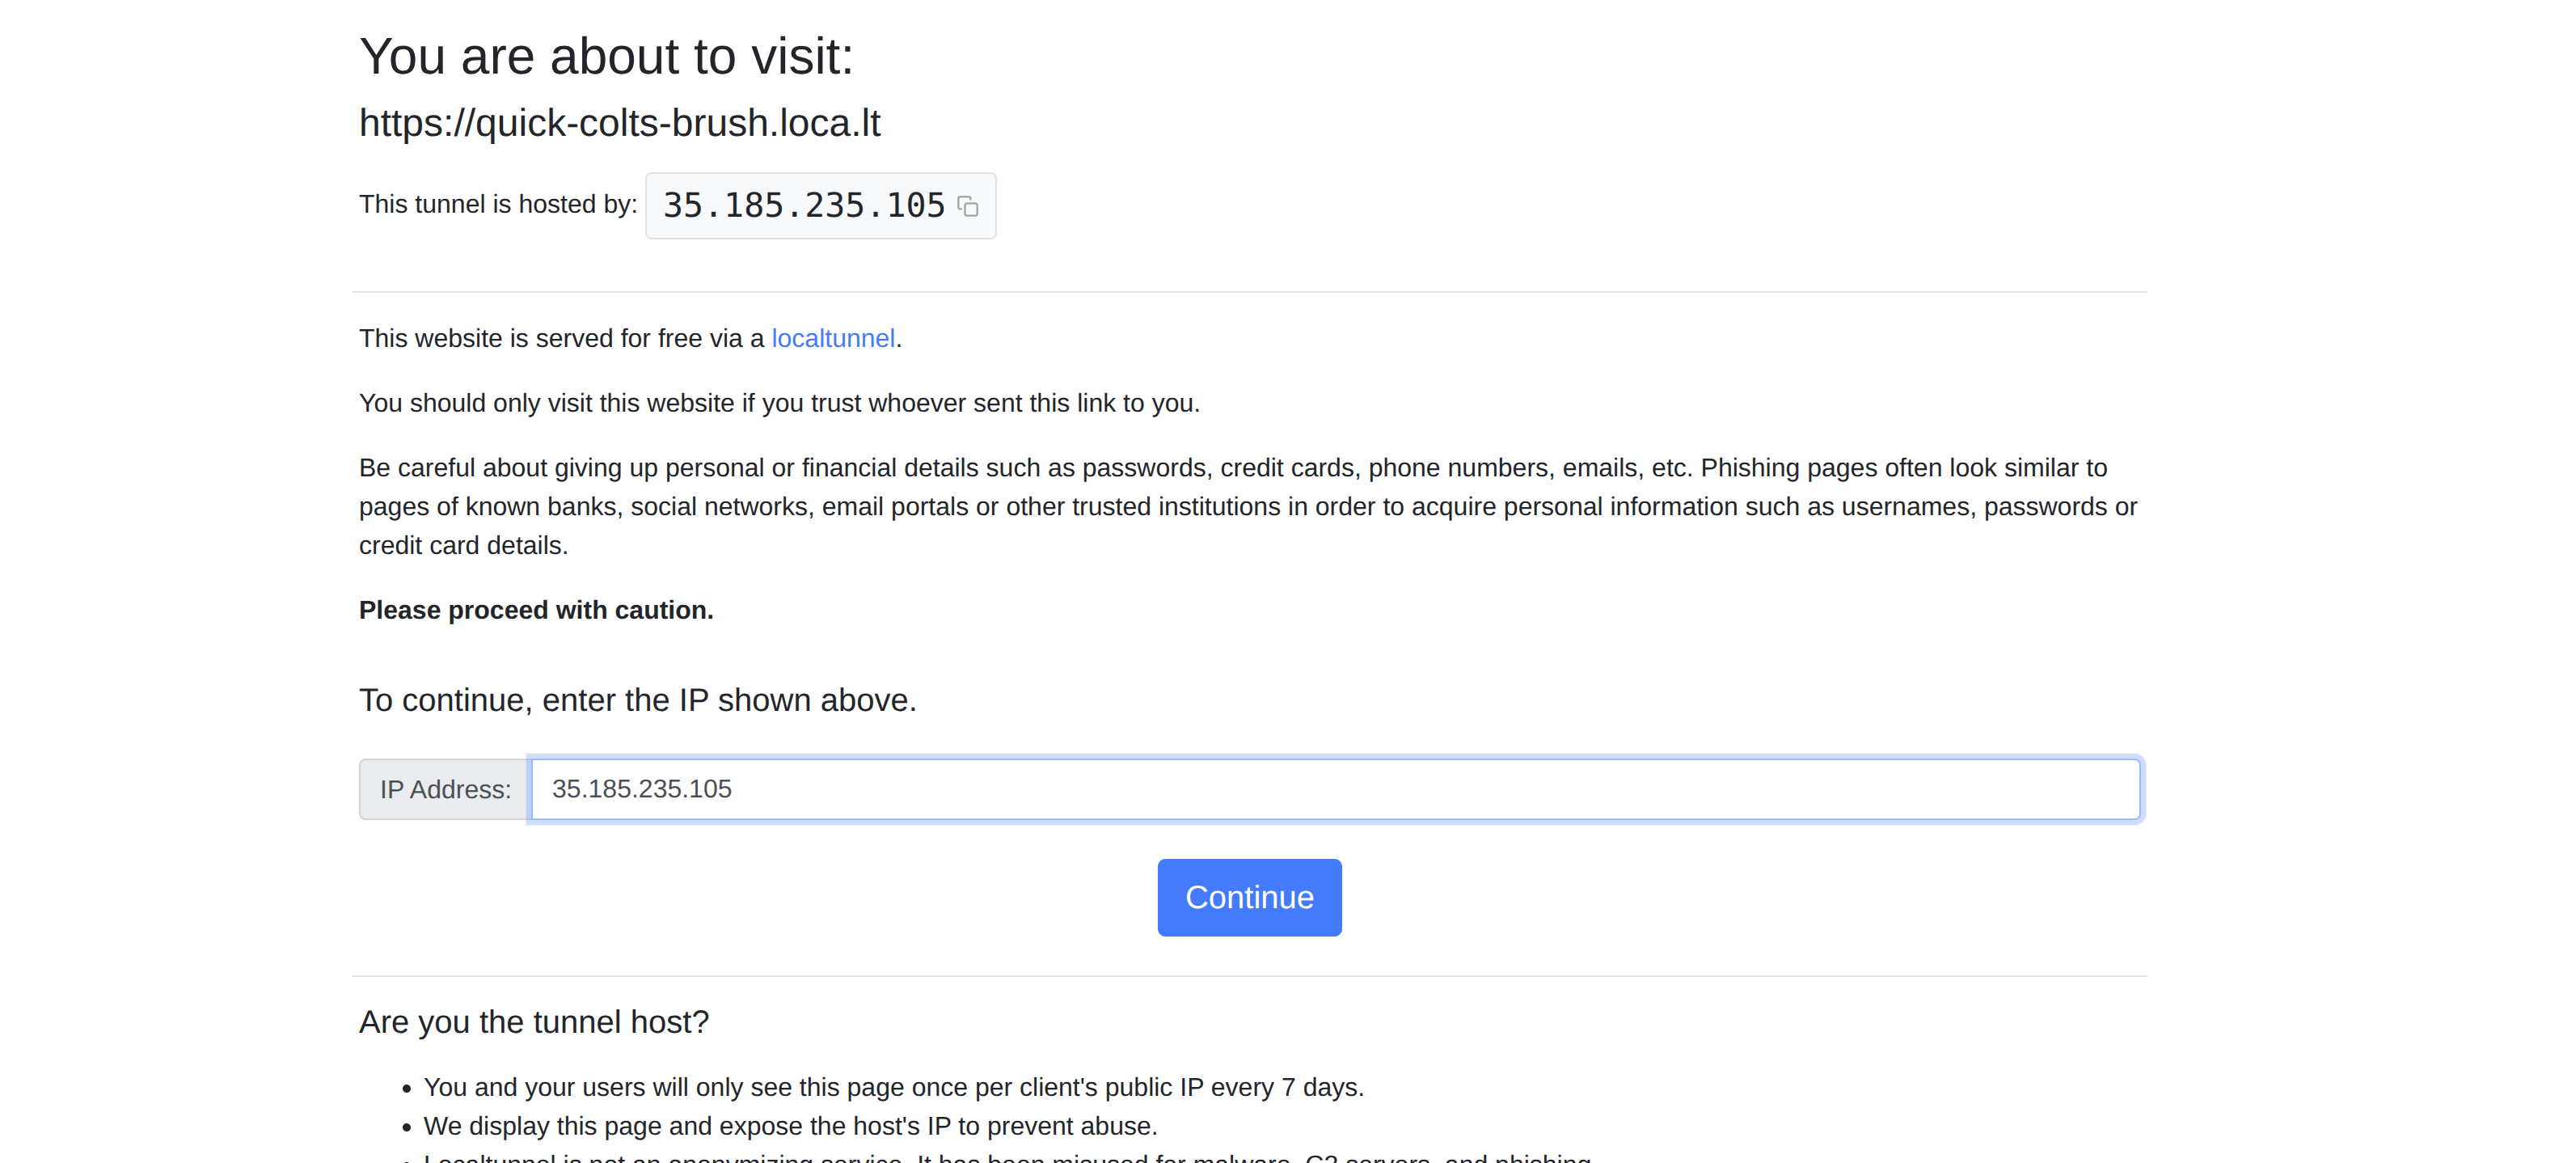

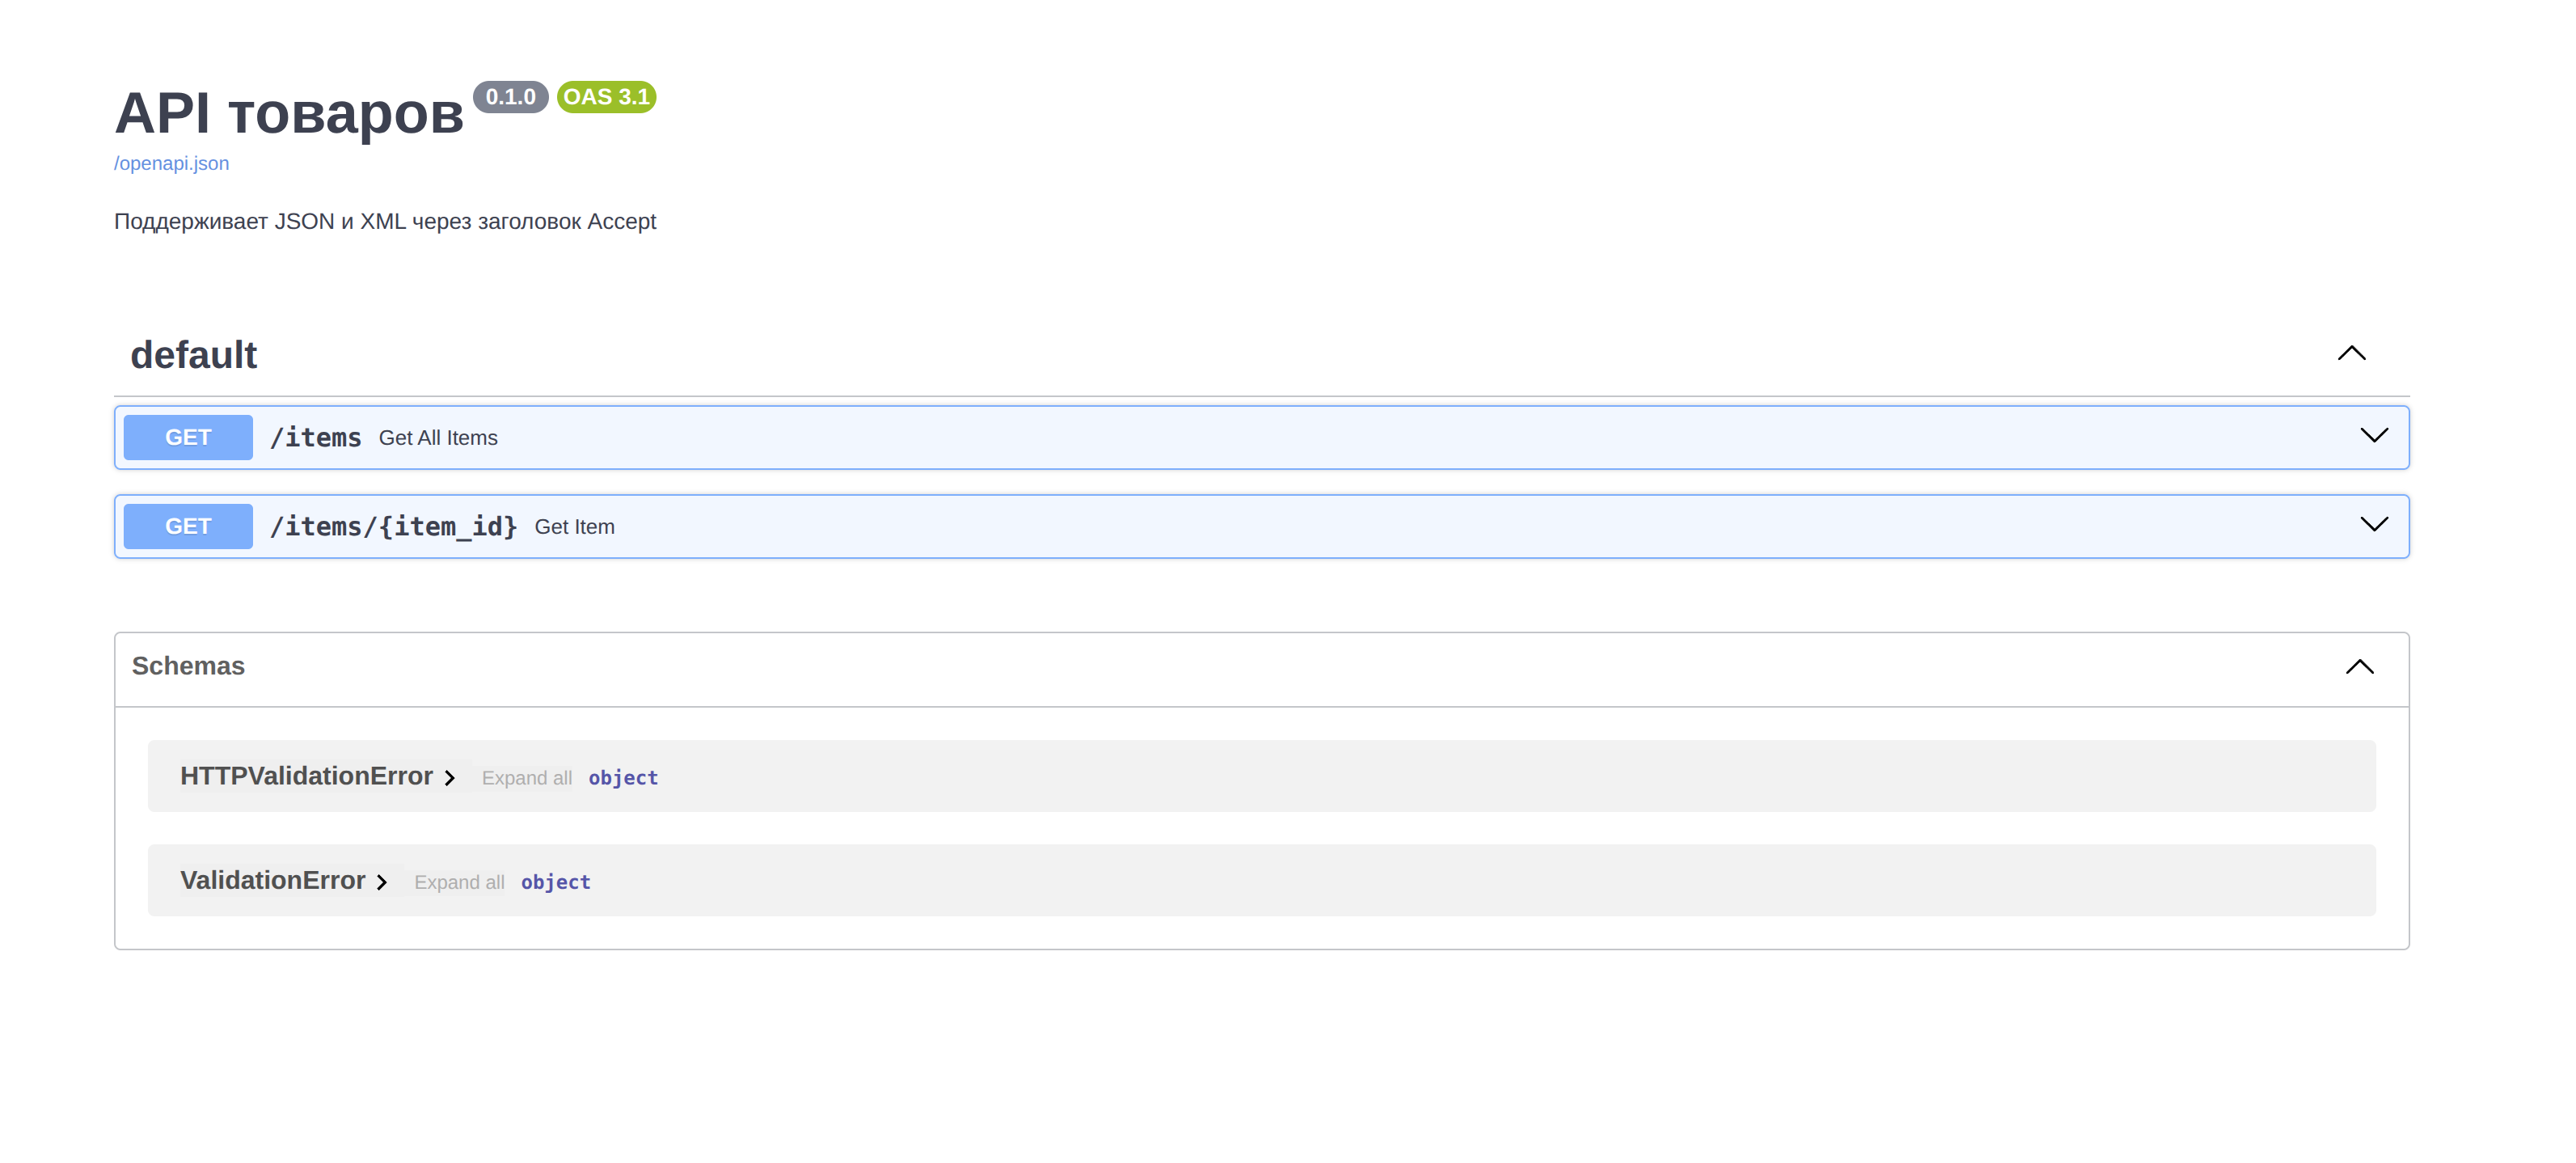

## Итоговое оформление


1. Проверьте, что ноутбук запускается.  
2. Сформулируйте ниже 5–8 выводов, когда стоит применять подход code-first и почему чаще стоит придерживаться подхода API-first.  



Прототипирование и небольшие проекты
Если API разрабатывается одним разработчиком или маленькой командой, а требования быстро меняются, проще сначала написать код, а документацию сгенерировать автоматически (FastAPI + OpenAPI). Это экономит время на начальном этапе

Внутренние API с единственным потребителем
Когда API используется только внутри одной команды или микросервиса, и все потребители находятся под вашим контролем, изменения можно вносить синхронно. Подход code‑first ускоряет итерации.

Согласование интерфейса до реализации
В крупных проектах с несколькими командами (клиентская, серверная, мобильная) сначала создаётся OpenAPI‑спецификация. Это позволяет всем сторонам одновременно вести разработку, а не ждать, пока бэкенд напишет код.

Упрощение версионирования
Когда спецификация хранится в репозитории как единственный источник истины, легко отследить различия между версиями API и обеспечить обратную совместимость (например, добавление полей, но не удаление).

Уменьшение количества breaking changes
При API‑first изменения проходят ревью на уровне контракта. Это снижает риск внезапного изменения полей, типов или статусов, которые сломают уже работающие клиенты.



## Примечание

Сохраните код работоспособного сервера из [ячейки](#scrollTo=EQRTmZPa2hi1).

Этот сервис пригодится для создания контейнеризированного приложения в ДЗ 4.

In [40]:
%%sh
git clone https://github.com/iagobalmeida/scalar_doc.git
cd scalar_doc
pip install .

Processing /content/scalar_doc
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for scalar_doc: filename=scalar_doc-0.1.8-py3-none-any.whl size=9857 sha256=94039376dfbbb52a225e0dc9b2e3cc20492132033da30f3ffa2d2ae65a920720
  Stored in directory: /tmp/pip-ephem-wheel-cache-o7i369nf/wheels/9e/24/41/5afc7c1fb9a3846058ec5900595433c40bda34d9fcbef4d11e
Successfully built scalar_doc
  Attempting uninstall: scalar_doc
    Found existing installation: scalar_doc 0.1.8
    Uninstalling scalar_doc-0.1.8:
      Successfully uninstalled scalar_doc-0.1.8


Cloning into 'scalar_doc'...
